In [120]:
'''
CUSTOMISABLE SCRIPT:

1) CUSTOMISE STRING TICKER SYMBOL 

2) ADJUST WINDOW PERIOD FOR SMA & EMA
'''

'\nCUSTOMISABLE SCRIPT:\n\n1) CUSTOMISE STRING TICKER SYMBOL \n\n2) ADJUST WINDOW PERIOD FOR SMA & EMA\n'

In [121]:
import yfinance as yf
import pandas as pd 
import numpy as np
from datetime import datetime, timedelta
import matplotlib.pyplot as plt 

In [122]:
TICKER = "MSFT"
WINDOW = 200
END = datetime.today()
START = END - timedelta(365 * 10)


In [123]:
def download_dataset(symbol):
    df = yf.download(TICKER, start=START, end=END)["Close"]
    return df

In [124]:
# calculate the 30 day simple moving average and exponential moving average
def moving_average_calculations(df):
    df["SMA"] = df[f"{TICKER}"].rolling(window=WINDOW).mean()
    df["EMA"] = df[f"{TICKER}"].ewm(span=WINDOW, adjust=False).mean()

In [125]:
# plot
def dataset_plot(df):
    plt.figure(figsize=(12,6))
    plt.plot(df[f"{TICKER}"], label=f"{TICKER} Closing Price")
    plt.plot(df["SMA"], label=f"{WINDOW} Day Simple Moving Average")
    plt.plot(df["EMA"],label="Exponential Moving Average")

    plt.title(f"{TICKER} Closing Price With The 30-DAY Simple And Exponential Moving Averages")
    plt.xlabel("Date")
    plt.ylabel("Price (in USD$) and Moving Averages")
    plt.grid(True)
    plt.legend(loc=2)
    plt.tight_layout()
    plt.show()

[*********************100%***********************]  1 of 1 completed


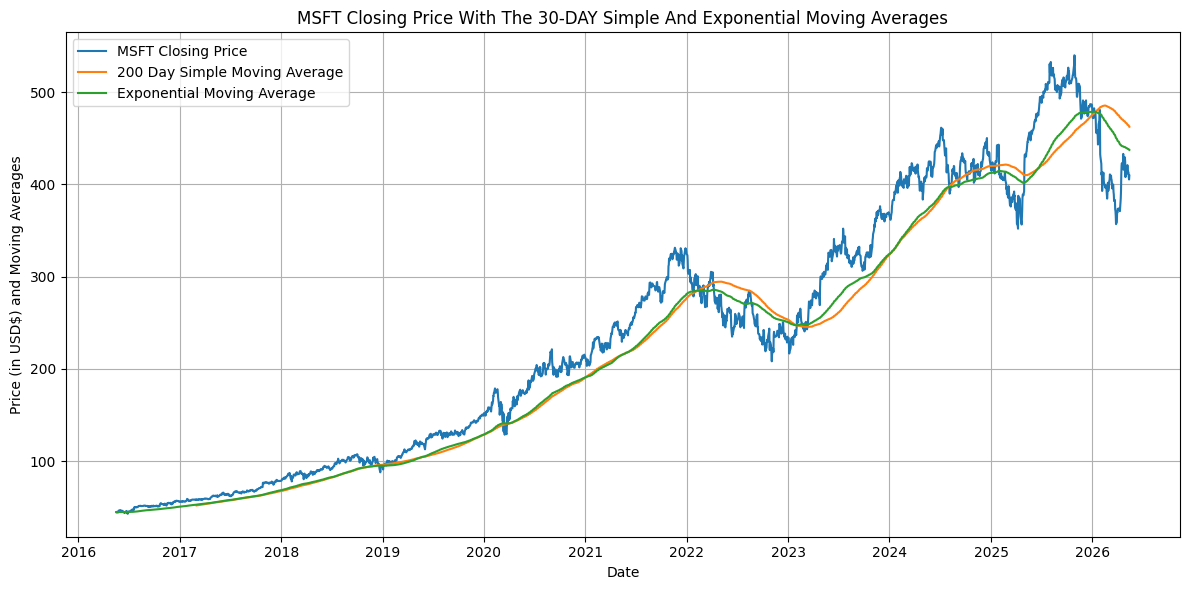

In [126]:
if __name__ == "__main__":
    df = download_dataset(TICKER)
    moving_average_calculations(df)
    dataset_plot(df)
    